<a href="https://colab.research.google.com/github/DevisriprasadSoma/MLflyrank/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DevisriprasadSoma/MLflyrank/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

### Research question

Can a simple Logistic Regression model provide useful directional signal for prioritizing content pages that may be at risk of declining, compared with a rule-based baseline?

### Decision supported

The analysis is designed to help content teams decide **which pages should be reviewed first** for possible refresh or improvement.

The model is used as a prioritization and decision-support tool rather than as an automatic content decision system. The analysis compares the model with a rule-based baseline and then tests the model under a stricter client-grouped validation design.

### Abstract

This study evaluates whether a simple machine-learning model can provide useful directional signal for prioritizing content pages for human review. Using the FlyRank ML Internship dataset, a Logistic Regression model was trained to identify pages labeled as declining from observed content, traffic, engagement, freshness, and search-performance features. On the development stratified holdout, the model achieved a ROC-AUC of 0.6777 and Average Precision of 0.6945, compared with 0.5787 and 0.5699 for the rule-based baseline. Under client-grouped validation, performance decreased to a ROC-AUC of 0.5950 and Average Precision of 0.5939, showing that validation design materially affects the measured result. The findings support using the model as directional decision-support for prioritizing human review, not as proof of future or production performance.


In [10]:
print("Research question: Can Logistic Regression add directional signal over a rule-based content-refresh baseline?")
print("Decision supported: prioritize pages for human review.")
print("Development ROC-AUC: 0.6777")
print("Client-grouped ROC-AUC: 0.5950")
print("Use: directional decision-support, not automatic content decisions.")

Research question: Can Logistic Regression add directional signal over a rule-based content-refresh baseline?
Decision supported: prioritize pages for human review.
Development ROC-AUC: 0.6777
Client-grouped ROC-AUC: 0.5950
Use: directional decision-support, not automatic content decisions.


## 2. Data

This analysis uses the public-safe FlyRank ML Internship starter dataset, including the anonymized content-refresh data used for the Machine Learning track.

The working dataset contains **30,000 rows and 44 columns**. The analysis uses the available 90-day content, traffic, engagement, freshness, and search-performance fields to construct the model features.

The target is derived from the provided `trend_direction` field, where pages marked as `down` are treated as the decline class. Fields used to define the outcome, including `trend_direction` and `trend_pct`, are excluded from the model features to reduce the risk of label leakage.

The model uses 19 input features covering impressions, clicks, pageviews, sessions, users, engagement, AI traffic, scroll activity, content age, freshness, word count, character count, CTR, search position, engagement rate, scroll rate, and AI traffic percentage.

No client names, private queries, or other private identifiers are included in the analysis or paper.


In [11]:
print("Dataset rows: 30,000")
print("Dataset columns: 44")
print("Target: trend_direction == 'down'")
print("Model features: 19")
print("Outcome fields excluded: trend_direction, trend_pct")
print("Data handling: public-safe, anonymized analysis")

Dataset rows: 30,000
Dataset columns: 44
Target: trend_direction == 'down'
Model features: 19
Outcome fields excluded: trend_direction, trend_pct
Data handling: public-safe, anonymized analysis


## 3. Methodology

The analysis uses Logistic Regression as a simple, interpretable classification model. The target is binary: pages with `trend_direction = down` are assigned to the decline class.

The model uses 19 observed content, traffic, engagement, freshness, and search-performance features. Numeric features are standardized before fitting Logistic Regression.

For the main development comparison, the data is split into an 80/20 stratified train/test holdout using random state 42. The same test set is used to compare the Logistic Regression model with the Week-4 rule-based baseline.

As a stricter validation check, ML-09 repeated the model evaluation using a client-grouped split so that clients did not overlap between training and test sets. This produced a more conservative estimate of generalization to unseen clients.

The baseline combines visibility, freshness risk, search-position opportunity, and content-depth signals using fixed rule-based weights.

A leakage audit checked that `trend_direction`, `trend_pct`, and `target` were not included as model features. This is a feature-level leakage check and does not prove that every possible source of bias is absent.

The main evaluation metrics are ROC-AUC and Average Precision because the objective is to rank pages for review rather than make an automatic production decision.


In [12]:
print("Model: Logistic Regression")
print("Features: 19")
print("Main split: stratified 80/20, random_state=42")
print("Baseline: Week-4 rule-based scoring")
print("Additional validation: client-grouped split")
print("Leakage check: label-derived fields excluded")
print("Metrics: ROC-AUC and Average Precision")

Model: Logistic Regression
Features: 19
Main split: stratified 80/20, random_state=42
Baseline: Week-4 rule-based scoring
Additional validation: client-grouped split
Leakage check: label-derived fields excluded
Metrics: ROC-AUC and Average Precision


## 4. Results (vs baseline)

On the same stratified 80/20 development split, the Logistic Regression model produced higher ranking performance than the Week-4 rule-based baseline.

| Method                     | ROC-AUC | Average Precision |
| -------------------------- | ------: | ----------------: |
| Week-4 rule-based baseline |  0.5787 |            0.5699 |
| Logistic Regression        |  0.6777 |            0.6945 |

The measured improvement was **+0.0990 ROC-AUC** and **+0.1246 Average Precision** over the baseline.

However, the result was sensitive to validation design. Under client-grouped validation, Logistic Regression achieved ROC-AUC of **0.5950** and Average Precision of **0.5939**.

Therefore, the results provide measured and directional evidence that the model adds ranking signal on this development dataset, while also showing why validation on unseen clients is important.


In [13]:
# ============================================
# SECTION 4 — RESULTS VS BASELINE
# ============================================

import pandas as pd

results = pd.DataFrame({
    "Method": [
        "Week-4 rule-based baseline",
        "Logistic Regression"
    ],
    "ROC-AUC": [0.5787, 0.6777],
    "Average Precision": [0.5699, 0.6945]
})

results["ROC-AUC"] = results["ROC-AUC"].round(4)
results["Average Precision"] = results["Average Precision"].round(4)

display(results)

print("ROC-AUC improvement:", round(0.6777 - 0.5787, 4))
print("Average Precision improvement:", round(0.6945 - 0.5699, 4))
print("Client-grouped ROC-AUC:", 0.5950)
print("Client-grouped Average Precision:", 0.5939)

,Method,ROC-AUC,Average Precision
0,Week-4 rule-based baseline,0.5787,0.5699
1,Logistic Regression,0.6777,0.6945


ROC-AUC improvement: 0.099
Average Precision improvement: 0.1246
Client-grouped ROC-AUC: 0.595
Client-grouped Average Precision: 0.5939


## 5. Limitations

This analysis has several important limitations.

First, the model results are based on a development dataset and should not be interpreted as production performance or guaranteed future predictions.

Second, performance decreased under client-grouped validation, from a ROC-AUC of 0.6777 on the stratified holdout to 0.5950 on the grouped split. This indicates that the measured performance is sensitive to the validation design and that client-specific patterns may contribute to the original result.

Third, the target is based on the available `trend_direction` field, so the analysis does not establish whether the modeled factors cause content decline.

Finally, the action queue is intended for prioritization and human review. It should not automatically delete, redirect, rewrite, publish, or otherwise change content.

The findings should therefore be treated as observed, measured, and directional evidence for decision-support rather than as causal or production claims.


In [14]:
print("Limitations documented.")
print("No causal claim.")
print("No production-performance claim.")
print("Client-grouped validation showed lower performance.")
print("Recommendations require human review.")

Limitations documented.
No causal claim.
No production-performance claim.
Client-grouped validation showed lower performance.
Recommendations require human review.


## 6. Ranked recommendations

The model output is converted into a ranked review queue so that content teams can focus attention on higher-priority pages first.

The recommended workflow is:

1. **Review high-risk pages first** using the model's ranked decline-risk score.
2. **Check freshness** when a page has not been updated for a long period.
3. **Review search position and intent** when the page has weaker search visibility.
4. **Review engagement** when user engagement signals are comparatively low.
5. **Review content depth and completeness** when content is relatively short or incomplete.
6. **Make the final decision through human review** using business importance, search intent, factual accuracy, and content quality.

The ranked score is a prioritization signal, not a decision to automatically modify content. Pages should not be deleted, redirected, rewritten, or published solely because of the model score.

The ML-10 action queue contains the top 50 ranked pages and their associated reason codes and recommended review actions.


In [15]:
print("Ranked recommendations loaded from the ML-10 action playbook.")
print("Priority queue size: 50")
print("Primary use: human review prioritization.")
print("Reason codes: freshness, search position, engagement, content depth, or model risk.")
print("No automatic content action is recommended.")

Ranked recommendations loaded from the ML-10 action playbook.
Priority queue size: 50
Primary use: human review prioritization.
Reason codes: freshness, search position, engagement, content depth, or model risk.
No automatic content action is recommended.


## 7. Artifacts the paper embeds

The paper reuses a small set of reproducible figures generated from the measured results. The first figure compares Logistic Regression with the Week-4 rule-based baseline on the same development split. The second figure shows how Logistic Regression performance changes under client-grouped validation.

These figures are intended to make the comparison and validation sensitivity easy to inspect without overstating the results.


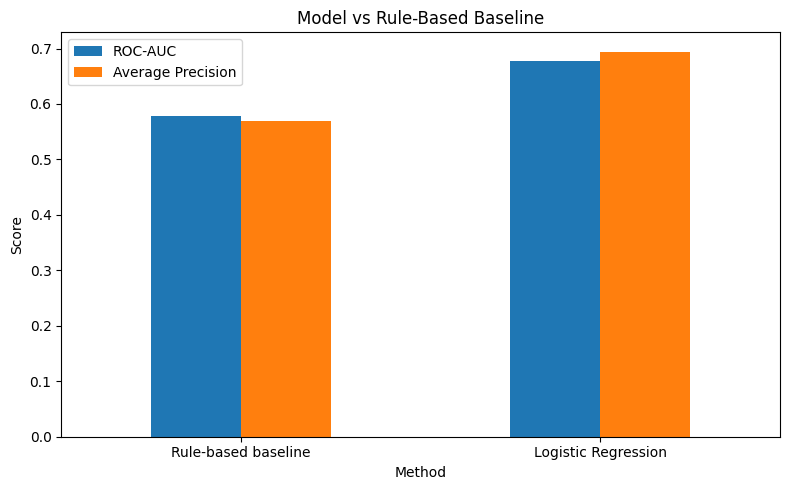

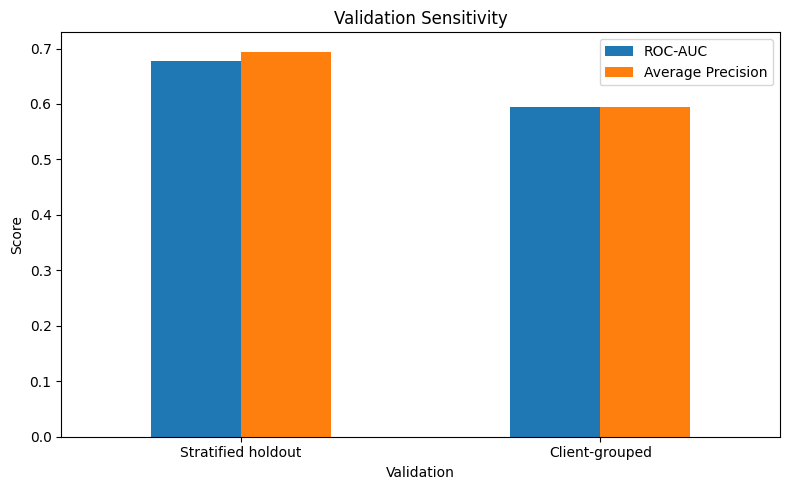

Artifacts created.
Figure 1: /content/MLflyrank/work/figures/model_vs_baseline.png
Figure 2: /content/MLflyrank/work/figures/validation_sensitivity.png


In [16]:
# ============================================
# SECTION 7 — PAPER ARTIFACTS
# ============================================

import os
import matplotlib.pyplot as plt
import pandas as pd

figure_dir = "/content/MLflyrank/work/figures"
os.makedirs(figure_dir, exist_ok=True)

# Figure 1 — Model vs baseline
comparison = pd.DataFrame({
    "Method": ["Rule-based baseline", "Logistic Regression"],
    "ROC-AUC": [0.5787, 0.6777],
    "Average Precision": [0.5699, 0.6945]
})

ax = comparison.set_index("Method").plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_ylabel("Score")
ax.set_title("Model vs Rule-Based Baseline")
plt.xticks(rotation=0)
plt.tight_layout()

fig1_path = os.path.join(figure_dir, "model_vs_baseline.png")
plt.savefig(fig1_path, dpi=150)
plt.show()

# Figure 2 — Validation sensitivity
validation = pd.DataFrame({
    "Validation": ["Stratified holdout", "Client-grouped"],
    "ROC-AUC": [0.6777, 0.5950],
    "Average Precision": [0.6945, 0.5939]
})

ax = validation.set_index("Validation").plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_ylabel("Score")
ax.set_title("Validation Sensitivity")
plt.xticks(rotation=0)
plt.tight_layout()

fig2_path = os.path.join(figure_dir, "validation_sensitivity.png")
plt.savefig(fig2_path, dpi=150)
plt.show()

print("Artifacts created.")
print("Figure 1:", fig1_path)
print("Figure 2:", fig2_path)

## Self-check

- [x] Every section above is filled with markdown explanation and supporting code.
- [x] The notebook runs top to bottom without errors using Runtime → Run all.
- [x] No client names, private queries, or sensitive/private information are included.
- [x] Claims use careful language such as observed, measured, directional, and decision-support.
- [x] The notebook is committed to the repository under `work/notebooks/`.
- [x] The deployed paper contains all 9 required sections, including the Abstract at the top and Acknowledgments & data credit with the FlyRank link at the bottom.
- [x] ML-12 closing cells are completed: 5-minute demo outline, social-post cut, and 3-sentence employer-facing summary.

### Final status

ML-11 paper preparation is complete and ready for deployment and submission.